In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt


(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print(f"Train: {x_train.shape}, Test: {x_test.shape}")  # (60000,28,28), (10000,28,28)

Train: (60000, 28, 28), Test: (10000, 28, 28)


In [7]:
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
y_train = keras.utils.to_categorical(y_train, 10)  # One-hot
y_test = keras.utils.to_categorical(y_test, 10)

print(f"После обработки: x_train {x_train.shape}, y_train {y_train.shape}")

После обработки: x_train (60000, 28, 28, 1), y_train (60000, 10)


In [9]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.GlobalAveragePooling2D(),  
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')  
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',  
              metrics=['accuracy'])

model.summary()


datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=12,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)


early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
history = model.fit(datagen.flow(x_train, y_train, batch_size=128),
                    steps_per_epoch=len(x_train)//128,
                    epochs=50, 
                    validation_data=(x_test, y_test),
                    callbacks=[early_stop],
                    verbose=1)


test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Тестовая точность: {test_acc*100:.2f}%")


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)                   │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 26, 26, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 24, 24, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 10, 10, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 10, 10, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 8, 8, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 4, 4, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 4, 4, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 4, 4, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 4, 4, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 512)                 │          66,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 358,506 (1.37 MB)

 Trainable params: 358,058 (1.37 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 68s 137ms/step - accuracy: 0.7389 - loss: 0.6958 - val_accuracy: 0.5523 - val_loss: 1.3092
Epoch 2/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7891 - loss: 0.5345 - val_accuracy: 0.5617 - val_loss: 1.2630
Epoch 3/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 66s 141ms/step - accuracy: 0.8245 - loss: 0.4776 - val_accuracy: 0.8212 - val_loss: 0.4934
Epoch 4/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8516 - loss: 0.4142 - val_accuracy: 0.8184 - val_loss: 0.5039
Epoch 5/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 67s 142ms/step - accuracy: 0.8456 - loss: 0.4230 - val_accuracy: 0.8635 - val_loss: 0.3716
Epoch 6/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8750 - loss: 0.3449 - val_accuracy: 0.8674 - val_loss: 0.3670
Epoch 7/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 66s 142ms/step - accuracy: 0.8563 - loss: 0.3928 - val_accuracy: 0.8583 - val_loss: 0.3667
Epoch 8/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8984 - loss: 0.2710 - val_

In [11]:
y_pred = model.predict(x_train).argmax(axis = 1)
y_pred

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step


array([9, 0, 0, ..., 3, 0, 5])

Матрица ошибок: (10, 10)


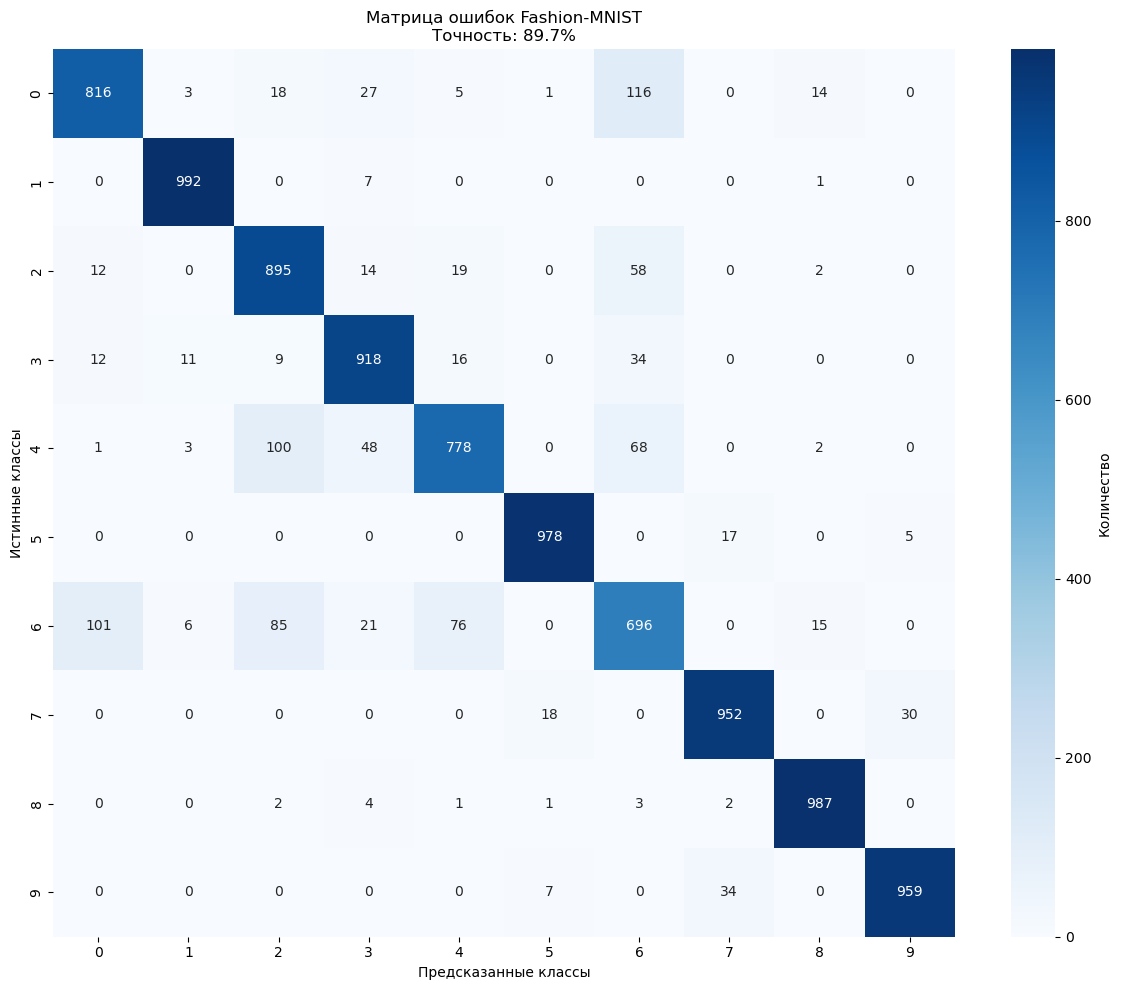

Подробный отчёт:
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1000
           1       0.98      0.99      0.98      1000
           2       0.81      0.90      0.85      1000
           3       0.88      0.92      0.90      1000
           4       0.87      0.78      0.82      1000
           5       0.97      0.98      0.98      1000
           6       0.71      0.70      0.70      1000
           7       0.95      0.95      0.95      1000
           8       0.97      0.99      0.98      1000
           9       0.96      0.96      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [18]:
from sklearn.metrics import confusion_matrix, classification_report


y_pred = model.predict(x_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)        
y_true_classes = np.argmax(y_test, axis=1)       


cm = confusion_matrix(y_true_classes, y_pred_classes)
print(f"Матрица ошибок: {cm.shape}")


plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10),
            cbar_kws={'label': 'Количество'})
plt.title(f'Матрица ошибок Fashion-MNIST\nТочность: {test_acc:.1%}')
plt.ylabel('Истинные классы')
plt.xlabel('Предсказанные классы')
plt.tight_layout()
plt.show()


print("Подробный отчёт:")
print(classification_report(y_true_classes, y_pred_classes))

In [19]:
x_train = x_train.reshape((60000, 28, 28, 1)).astype('float32') / 255
x_test = x_test.reshape((10000, 28, 28, 1)).astype('float32') / 255

mean_image = np.mean(x_train, axis=0)
x_train -= mean_image
x_test -= mean_image

df_features = df_all.drop('label', axis=1)

print({df_features.shape})

{(70000, 784)}


In [22]:
from sklearn.preprocessing import StandardScaler
from tensorflow import keras


(x_train_raw, y_train), (x_test_raw, y_test) = keras.datasets.fashion_mnist.load_data()


x_train_scaled = x_train_raw.reshape(60000, -1) / 255.0  
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_scaled)     

x_test_scaled = x_test_raw.reshape(10000, -1) / 255.0
x_test_scaled = scaler.transform(x_test_scaled)

In [23]:
def create_pairs(x_train_scaled, x_test_scaled, y_train, y_test):
    tensor_train = []
    tensor_test = []
    for i in range(len(x_train_scaled)):
        tensor_train.append([x_train_scaled[i], y_train[i]])
    for i in range(len(x_test_scaled)):
        tensor_test.append([x_test_scaled[i], y_test[i]])
    return tensor_train, tensor_test

In [24]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

tensor_train, tensor_test = create_pairs(x_train_scaled, x_test_scaled, y_train, y_test)
batch_size = 32
train_loader = torch.utils.data.DataLoader(dataset=tensor_train,
                                            batch_size=batch_size,
                                            shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=tensor_test,
                                          batch_size=batch_size,
                                          shuffle=False)

# Определение модели
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(NeuralNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        
    def forward(self, x):
        out = self.conv(x)
        out = self.pool(out)
        out = self.softmax1(out)
        out = self.dropout1(out)
        
        out = self.fc2(out)
        out = self.bn_2(out)
        out = self.softmax2(out)
        out = self.dropout2(out)
        
        out = self.fc3(out)
        return out


In [25]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)), 
    layers.MaxPooling2D((2, 2)),                                         
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),                                          
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),                                          
    layers.Conv2D(64, (3, 3), padding = 'same', activation='relu'), 
    layers.Flatten(),                                                      
    layers.Dense(64, activation='relu'),                                   
    layers.Dense(10, activation='softmax')                                 
])

C:\Users\user\Downloads\UDL Downloads\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

In [30]:
class CNN(nn.Module):
    def init__(self, in_channels, num_classes):  # ИСПРАВЛЕНО: __init
        super(CNN, self).__init__()  # ИСПРАВЛЕНО: init

        # 1st convolutional layer
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, padding=1)
        # Max pooling layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # 2nd convolutional layer
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
        # Adaptive pooling + flatten
        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))
        # Fully connected layer
        self.fc1 = nn.Linear(16 * 7 * 7, num_classes)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        # 1st block: Conv1 → ReLU → Pool
        x = self.pool(F.relu(self.conv1(x)))
        # 2nd block: Conv2 → ReLU → Pool → AdaptivePool
        x = self.pool(F.relu(self.conv2(x)))
        x = self.adaptive_pool(x)
        # Flatten
        x = x.view(-1, 16 * 7 * 7)
        # FC + Dropout + Logits
        x = self.dropout(F.relu(self.fc1(x)))
        return x  # Logits для CrossEntropyLoss


In [31]:

transform = transforms.Compose([
    transforms.ToTensor(),  # → (1,28,28), нормализация 0-1
    transforms.Normalize((0.5,), (0.5,))  # → [-1,1]
])

# Датасеты
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train: {len(train_dataset)} batches: {len(train_loader)}")
print(f"Test:  {len(test_dataset)} batches: {len(test_loader)}")

Train: 60000 batches: 938
Test:  10000 batches: 157


In [34]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется: {device}")


class CNN(nn.Module):
    def __init__(self, in_channels, num_classes):  
        super(CNN, self).__init__()  
        
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(16 * 7 * 7, num_classes)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 7 * 7)
        x = F.relu(self.fc1(x))
        return x

model = CNN(in_channels=1, num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Всего параметров: {total_params:,}")

Используется: cpu
CNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=784, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)
Всего параметров: 9,098


In [35]:
def train_model(model, train_loader, criterion, optimizer, epochs=10):
    model.train()
    train_losses, train_accs = [], []
    
    for epoch in range(epochs):
        running_loss, correct, total = 0.0, 0, 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.numel()
        
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100. * correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)
        
        print(f'Epoch {epoch+1}/{epochs}: Loss={epoch_loss:.4f}, Acc={epoch_acc:.1f}%')
    
    return train_losses, train_accs

# Обучение
history = train_model(model, train_loader, criterion, optimizer, epochs=10)

Epoch 1/10: Loss=0.9790, Acc=66.1%
Epoch 2/10: Loss=0.8146, Acc=70.7%
Epoch 3/10: Loss=0.7749, Acc=71.6%
Epoch 4/10: Loss=0.7534, Acc=72.2%
Epoch 5/10: Loss=0.7369, Acc=72.7%
Epoch 6/10: Loss=0.7240, Acc=73.0%
Epoch 7/10: Loss=0.7157, Acc=73.1%
Epoch 8/10: Loss=0.7058, Acc=73.5%
Epoch 9/10: Loss=0.7013, Acc=73.6%
Epoch 10/10: Loss=0.6948, Acc=73.7%
